In [1]:
using LinearAlgebra
using LinearOperators
using SparseArrays

In [2]:
function get_1d_laplace_op_matrix(n)
	off = ones(n-1)
	diag = ones(n)
	spdiagm(-1 => off, 0 => -2diag, 1 => off)
end

get_1d_laplace_op_matrix (generic function with 1 method)

In [3]:
# L
# E L, L E
# E E L, E L E, L E E
# E E E L, E E L E, E L E E, L E E E
# (E E E L), (E E L) (E), (E L) (E E), (L) (E E E)
# E ... E L = L of size n^(k+1) if E is there k times
function get_laplace_op_matrix(n, d)
	L_full = get_1d_laplace_op_matrix(n^d)
	for k in 1:(d-1)
		L = get_1d_laplace_op_matrix(n^(d-k))
		size = n^k
		E = sparse(I, size, size)
		L_full += kron(L, E)
	end
	L_full
end

# 4 points, 3 dims
#get_laplace_op_matrix(4, 3)

get_laplace_op_matrix (generic function with 1 method)

In [4]:
#Matrix(L_full)

## define RHS and solve using different methods

$\Delta u = f \:\:\text{on}\:\:\Omega$

$u = g \:\:\text{on}\:\:\partial\Omega$

supp 1D:

$ \partial u / \partial x \approx \frac{u(x+h/2) - u(x-h/2)}{h}$

$\Delta u(x) \approx \frac{u(x+h) - 2u(x) + u(x-h)}{h^2}$

$ u_{i-1} - 2u_i + u_{i+1} = h^2 f_i$

$ i = 0,1,...,n,n+1 $

boundary: $\:i=0, \:i=n+1 $

we know $\:u_0, \:u_{n+1}\:$ from BC

we need $n$ equation for $n$ unknowns ($u_1,...,u_n$)

$ u_0 - 2u_1 + u_2 = h^2 f_1 $

$ u_1 - 2u_2 + u_3 = h^2 f_2 $

...

$ u_{n-2} - 2u_{n-1} + u_{n} = h^2 f_{n-1} $

$ u_{n-1} - 2u_n + u_{n+1} = h^2 f_n $

we get

$ L U = F $

where
- $L$ matrix of size $n \times n$
- $U = (u_1, u_2, ..., u_{n-1}, u_n)$
- $F = h^2(f_1, f_2, ..., f_{n-1}, f_n) - (u_0, 0, ..., 0, u_{n+1})$

In [5]:
n = 100
d = 2
N = n^d

10000

In [6]:
h = 1 / (n+1)

0.009900990099009901

In [7]:
function u_analytic_fun(x)
    #prod(x)*prod(1 .- x)
    prod(sin.(pi*x))
end

function f_fun(x)
    d = length(x)
    -d*pi^2 * prod(sin.(pi*x))
end

f_fun (generic function with 1 method)

### fiddling around

In [8]:
v = Vector([1,2,3])
v, f_fun(v)

([1, 2, 3], 3.262907826717048e-46)

In [9]:
v = Vector([Vector([1,2,3]), Vector([1,1,1])])
v, f_fun.(v)

([[1, 2, 3], [1, 1, 1]], [3.262907826717048e-46, -5.438179711195081e-47])

In [10]:
xs = [range(h, 1-h; length=n) for _ in 1:d]

2-element Vector{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}:
 0.009900990099009901:0.009900990099009901:0.9900990099009901
 0.009900990099009901:0.009900990099009901:0.9900990099009901

In [11]:
coords = collect(Iterators.product(xs...))

100×100 Matrix{Tuple{Float64, Float64}}:
 (0.00990099, 0.00990099)  (0.00990099, 0.019802)  …  (0.00990099, 0.990099)
 (0.019802, 0.00990099)    (0.019802, 0.019802)       (0.019802, 0.990099)
 (0.029703, 0.00990099)    (0.029703, 0.019802)       (0.029703, 0.990099)
 (0.039604, 0.00990099)    (0.039604, 0.019802)       (0.039604, 0.990099)
 (0.049505, 0.00990099)    (0.049505, 0.019802)       (0.049505, 0.990099)
 (0.0594059, 0.00990099)   (0.0594059, 0.019802)   …  (0.0594059, 0.990099)
 (0.0693069, 0.00990099)   (0.0693069, 0.019802)      (0.0693069, 0.990099)
 (0.0792079, 0.00990099)   (0.0792079, 0.019802)      (0.0792079, 0.990099)
 (0.0891089, 0.00990099)   (0.0891089, 0.019802)      (0.0891089, 0.990099)
 (0.0990099, 0.00990099)   (0.0990099, 0.019802)      (0.0990099, 0.990099)
 (0.108911, 0.00990099)    (0.108911, 0.019802)    …  (0.108911, 0.990099)
 (0.118812, 0.00990099)    (0.118812, 0.019802)       (0.118812, 0.990099)
 (0.128713, 0.00990099)    (0.128713, 0.019802)     

In [12]:
collect(coords[1])

2-element Vector{Float64}:
 0.009900990099009901
 0.009900990099009901

In [13]:
[collect(coords[1]), collect(coords[2])]

2-element Vector{Vector{Float64}}:
 [0.009900990099009901, 0.009900990099009901]
 [0.019801980198019802, 0.009900990099009901]

In [14]:
f_fun.([collect(coords[1]), collect(coords[2])])

2-element Vector{Float64}:
 -0.019091791043757085
 -0.03816511201270312

In [15]:
#grid_points_as_1d_vect = [collect(x) for x in coords[1:end]]
#f_fun.(grid_points_as_1d_vect)

### here we go

In [16]:
function get_grid_points_as_1d_vect(n, d)
    a = 0
    b = 1
    h = 1/(n+1)
    xs = [range(h, 1-h; length=n) for _ in 1:d]
    coords = collect(Iterators.product(xs...))
    [collect(x) for x in coords[1:end]]
end
#f.(grid_points_as_1d_vect)

get_grid_points_as_1d_vect (generic function with 1 method)

In [17]:
n^d

10000

In [18]:
grid_points_as_1d_vect = get_grid_points_as_1d_vect(n,d);

In [19]:
U_analytic = u_analytic_fun.(grid_points_as_1d_vect);

In [20]:
f = f_fun.(grid_points_as_1d_vect);
F = h^2 * f;

In [21]:
L = get_laplace_op_matrix(n,d);

In [22]:
Matrix(L);

In [23]:
using IterativeSolvers
U_cg = cg(L, F)

10000-element Vector{Float64}:
 0.01928132630789413
 0.02633233541903
 0.029419758808380887
 0.031039314542434384
 0.03203835238350517
 0.03274289792281522
 0.0332944641374758
 0.03376132516090135
 0.034179370023113255
 0.03456873581498859
 0.03494125564067625
 0.03530408418547458
 0.03566159320233715
 ⋮
 0.0353040841854746
 0.03494125564067628
 0.0345687358149886
 0.03417937002311324
 0.0337613251609013
 0.03329446413747585
 0.03274289792281526
 0.03203835238350517
 0.03103931454243434
 0.02941975880838084
 0.026332335419029986
 0.019281326307894094

In [24]:
U_direct = L \ F;

In [25]:
length(U_cg)

10000

In [26]:
z = [U_cg[i*n+j] for i in 0:(n-1), j in 1:n]

100×100 Matrix{Float64}:
 0.0192813  0.0263323  0.0294198  …  0.0378582  0.0393133  0.0425209
 0.0507911  0.0566245  0.0603018     0.0749975  0.0768704  0.0799773
 0.0847339  0.0890654  0.0924599     0.111367   0.113186   0.11578
 0.119096   0.122432   0.125407      0.147098   0.148714   0.150857
 0.153431   0.156144   0.158764      0.182314   0.183701   0.185493
 0.187619   0.18993    0.192285   …  0.217094   0.218266   0.219786
 0.22161    0.223651   0.225816      0.251483   0.25246    0.253764
 0.25537    0.257222   0.259253      0.285497   0.2863     0.287429
 0.288869   0.290584   0.292521      0.319139   0.319786   0.320766
 0.322077   0.32369    0.325563      0.352398   0.352904   0.353758
 0.354963   0.356499   0.358329   …  0.385261   0.385636   0.386379
 0.387497   0.388975   0.390778      0.417706   0.417962   0.418606
 0.41965    0.421082   0.422869      0.449711   0.449855   0.45041
 ⋮                                ⋱                        
 0.418606   0.417962   0.417706

In [27]:
U_analytic - U_direct;

In [28]:
U_cg - U_direct;

### operator playground

In [51]:
v = collect((1:1:N));

In [52]:
# Reshape the vector to a grid of values
U = reshape(v, ntuple(i -> n, d)) 

100×100 Matrix{Int64}:
   1  101  201  301  401  501  601  …  9401  9501  9601  9701  9801   9901
   2  102  202  302  402  502  602     9402  9502  9602  9702  9802   9902
   3  103  203  303  403  503  603     9403  9503  9603  9703  9803   9903
   4  104  204  304  404  504  604     9404  9504  9604  9704  9804   9904
   5  105  205  305  405  505  605     9405  9505  9605  9705  9805   9905
   6  106  206  306  406  506  606  …  9406  9506  9606  9706  9806   9906
   7  107  207  307  407  507  607     9407  9507  9607  9707  9807   9907
   8  108  208  308  408  508  608     9408  9508  9608  9708  9808   9908
   9  109  209  309  409  509  609     9409  9509  9609  9709  9809   9909
  10  110  210  310  410  510  610     9410  9510  9610  9710  9810   9910
  11  111  211  311  411  511  611  …  9411  9511  9611  9711  9811   9911
  12  112  212  312  412  512  612     9412  9512  9612  9712  9812   9912
  13  113  213  313  413  513  613     9413  9513  9613  9713  9813   9913
  

In [31]:
vec(U)

10000-element Vector{Int64}:
     1
     2
     3
     4
     5
     6
     7
     8
     9
    10
    11
    12
    13
     ⋮
  9989
  9990
  9991
  9992
  9993
  9994
  9995
  9996
  9997
  9998
  9999
 10000

In [48]:
circshift(U, (1,0))

100×100 Matrix{Int64}:
 100  200  300  400  500  600  700  …  9500  9600  9700  9800  9900  10000
   1  101  201  301  401  501  601     9401  9501  9601  9701  9801   9901
   2  102  202  302  402  502  602     9402  9502  9602  9702  9802   9902
   3  103  203  303  403  503  603     9403  9503  9603  9703  9803   9903
   4  104  204  304  404  504  604     9404  9504  9604  9704  9804   9904
   5  105  205  305  405  505  605  …  9405  9505  9605  9705  9805   9905
   6  106  206  306  406  506  606     9406  9506  9606  9706  9806   9906
   7  107  207  307  407  507  607     9407  9507  9607  9707  9807   9907
   8  108  208  308  408  508  608     9408  9508  9608  9708  9808   9908
   9  109  209  309  409  509  609     9409  9509  9609  9709  9809   9909
  10  110  210  310  410  510  610  …  9410  9510  9610  9710  9810   9910
  11  111  211  311  411  511  611     9411  9511  9611  9711  9811   9911
  12  112  212  312  412  512  612     9412  9512  9612  9712  9812   9912
  

In [34]:
A = circshift(U, (1,0));
A[1,:] .= 0;
A

100×100 Matrix{Int64}:
  0    0    0    0    0    0    0    0  …     0     0     0     0     0     0
  1  101  201  301  401  501  601  701     9401  9501  9601  9701  9801  9901
  2  102  202  302  402  502  602  702     9402  9502  9602  9702  9802  9902
  3  103  203  303  403  503  603  703     9403  9503  9603  9703  9803  9903
  4  104  204  304  404  504  604  704     9404  9504  9604  9704  9804  9904
  5  105  205  305  405  505  605  705  …  9405  9505  9605  9705  9805  9905
  6  106  206  306  406  506  606  706     9406  9506  9606  9706  9806  9906
  7  107  207  307  407  507  607  707     9407  9507  9607  9707  9807  9907
  8  108  208  308  408  508  608  708     9408  9508  9608  9708  9808  9908
  9  109  209  309  409  509  609  709     9409  9509  9609  9709  9809  9909
 10  110  210  310  410  510  610  710  …  9410  9510  9610  9710  9810  9910
 11  111  211  311  411  511  611  711     9411  9511  9611  9711  9811  9911
 12  112  212  312  412  512  612  712   

In [57]:
LU = zeros(size(U));
LU[:, 2:end] .+= U[:, 1:end-1]
LU[:, 1:end-1] .+= U[:, 2:end]
LU[2:end, :] .+= U[1:end-1, :]
LU[1:end-1, :] .+= U[2:end, :]
LU .-= 2*d*U
LU

100×100 Matrix{Float64}:
   99.0  -100.0  -200.0  -300.0  …  -9600.0  -9700.0  -9800.0  -19901.0
   98.0     0.0     0.0     0.0         0.0      0.0      0.0  -10002.0
   97.0     0.0     0.0     0.0         0.0      0.0      0.0  -10003.0
   96.0     0.0     0.0     0.0         0.0      0.0      0.0  -10004.0
   95.0     0.0     0.0     0.0         0.0      0.0      0.0  -10005.0
   94.0     0.0     0.0     0.0  …      0.0      0.0      0.0  -10006.0
   93.0     0.0     0.0     0.0         0.0      0.0      0.0  -10007.0
   92.0     0.0     0.0     0.0         0.0      0.0      0.0  -10008.0
   91.0     0.0     0.0     0.0         0.0      0.0      0.0  -10009.0
   90.0     0.0     0.0     0.0         0.0      0.0      0.0  -10010.0
   89.0     0.0     0.0     0.0  …      0.0      0.0      0.0  -10011.0
   88.0     0.0     0.0     0.0         0.0      0.0      0.0  -10012.0
   87.0     0.0     0.0     0.0         0.0      0.0      0.0  -10013.0
    ⋮                            ⋱     

In [54]:
LU = zeros(size(U));
A = circshift(U, (1,0));
A[1,:] .= 0;
LU .+= A;
A = circshift(U, (-1,0));
A[end,:] .= 0;
LU .+= A;

A = circshift(U, (0,1));
A[:,1] .= 0;
LU .+= A;
A = circshift(U, (0,-1));
A[:,end] .= 0;
LU .+= A;

LU .-= 2*d*U;
LU

100×100 Matrix{Float64}:
   99.0  -100.0  -200.0  -300.0  …  -9600.0  -9700.0  -9800.0  -19901.0
   98.0     0.0     0.0     0.0         0.0      0.0      0.0  -10002.0
   97.0     0.0     0.0     0.0         0.0      0.0      0.0  -10003.0
   96.0     0.0     0.0     0.0         0.0      0.0      0.0  -10004.0
   95.0     0.0     0.0     0.0         0.0      0.0      0.0  -10005.0
   94.0     0.0     0.0     0.0  …      0.0      0.0      0.0  -10006.0
   93.0     0.0     0.0     0.0         0.0      0.0      0.0  -10007.0
   92.0     0.0     0.0     0.0         0.0      0.0      0.0  -10008.0
   91.0     0.0     0.0     0.0         0.0      0.0      0.0  -10009.0
   90.0     0.0     0.0     0.0         0.0      0.0      0.0  -10010.0
   89.0     0.0     0.0     0.0  …      0.0      0.0      0.0  -10011.0
   88.0     0.0     0.0     0.0         0.0      0.0      0.0  -10012.0
   87.0     0.0     0.0     0.0         0.0      0.0      0.0  -10013.0
    ⋮                            ⋱     

In [36]:
eye = 1*I(d)

2×2 Diagonal{Int64, Vector{Int64}}:
 1  ⋅
 ⋅  1

In [37]:
Tuple(eye[:,1])

(1, 0)

In [38]:
LU = zeros(size(U));
# apply the stencil on every value on the grid
for dim in 1:d
    # roll forward
    A = circshift(U, Tuple(eye[:,dim]))
    index = ntuple(i -> i == dim ? 1 : Colon(), d)
    A[index...] .= 0
    LU .+= A
    # roll backward
    A = circshift(U, Tuple(-eye[:,dim]))
    index = ntuple(i -> i == dim ? n : Colon(), d)
    A[index...] .= 0
    LU .+= A
    # -2
    LU .-= 2*d*U
end
LU;

In [39]:
side = :last
dim = 2
sz = size(U)
index = ntuple(i -> i == dim ? (side == :first ? 1 : sz[dim]) : Colon(), ndims(U))

(Colon(), 100)

In [40]:
d

2

In [41]:
ntuple(i -> i == dim ? 1 : Colon(), d)
ntuple(i -> i == dim ? n : Colon(), d)

(Colon(), 100)

In [ ]:
LU = zeros(size(U));
LU[:, 2:end] .+= U[:, 1:end-1]
LU[:, 1:end-1] .+= U[:, 2:end]
LU[2:end, :] .+= U[1:end-1, :]
LU[1:end-1, :] .+= U[2:end, :]
LU .-= 2*d*U
LU;

In [90]:
LU = zeros(size(U));
for dim in 1:d
    index_rs = ntuple(i -> i == dim ? (2:n) : Colon(), d)
    index_ls = ntuple(i -> i == dim ? (1:(n-1)) : Colon(), d)
    LU[index_rs...] .+= U[index_ls...]
    LU[index_ls...] .+= U[index_rs...]
end
LU .-= 2*d*U
LU;

### operator - here we go

In [78]:
#function laplace_operator(v, n, d)
#function laplace_operator_1(v)
function laplace_operator!(v_new, v)

    # from vector of value to values on a grid
    U = reshape(v, ntuple(i -> n, d)) 

    # apply the laplace stencil on every value on the grid
    LU = zeros(size(U));
    for dim in 1:d
        index_rs = ntuple(i -> i == dim ? (2:n) : Colon(), d)
        index_ls = ntuple(i -> i == dim ? (1:(n-1)) : Colon(), d)
        LU[index_rs...] .+= U[index_ls...]
        LU[index_ls...] .+= U[index_rs...]
    end
    LU .-= 2*d*U

    v_new .= vec(LU)
end


laplace_operator! (generic function with 1 method)

In [79]:
L_op = LinearOperator(Float64, N, N, true, true, laplace_operator!)

Linear operator
  nrow: 10000
  ncol: 10000
  eltype: Float64
  symmetric: true
  hermitian: true
  nprod:   0
  ntprod:  0
  nctprod: 0



In [80]:
U_cg_op = cg(L_op, F; maxiter=100, verbose=true)

  1	2.95e-14



10000-element Vector{Float64}:
 0.0009672794186726168
 0.001933623056978419
 0.0028980960398576595
 0.0038597653019889037
 0.004817700490469464
 0.005770974864871746
 0.0067186661938047725
 0.007659857647113467
 0.00859363868285264
 0.009519105928177516
 0.010435364053298582
 0.011341526637655388
 0.012236717027471148
 ⋮
 0.011341526637655499
 0.01043536405329868
 0.009519105928177597
 0.008593638682852723
 0.007659857647113536
 0.006718666193804828
 0.005770974864871805
 0.00481770049046952
 0.0038597653019889484
 0.0028980960398576902
 0.0019336230569784367
 0.0009672794186726344

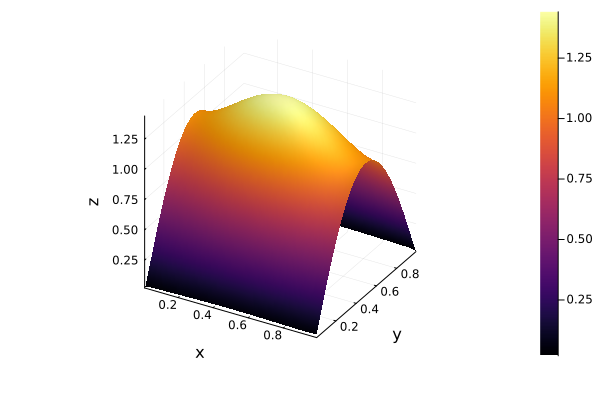

In [89]:
if d == 2
    using Plots

    # Create a grid
    x = y = h:h:(1-h)
    z = [F[i*n+j] for i in 0:(n-1), j in 1:n]
    z = [U_analytic[i*n+j] for i in 0:(n-1), j in 1:n]
    z = [U_cg_op[i*n+j] for i in 0:(n-1), j in 1:n]

    z = [U_direct[i*n+j] for i in 0:(n-1), j in 1:n]
    z = [U_cg[i*n+j] for i in 0:(n-1), j in 1:n]

    # Make the surface plot
    surface(x, y, z, xlabel="x", ylabel="y", zlabel="z")
end

In [46]:
#using CairoMakie
#CairoMakie.activate!()
#grid_points = collect(range(h,1-h, length=n));
#scatter(grid_points, U_analytic, color=:gray0)
#lines!(grid_points, U_cg, color=:gray0)
#current_figure()

In [47]:
#n_trials = 8
#n_mult = 8
#max_jacobi = zeros(n_trials)
#max_gs = zeros(n_trials)
#max_direct = zeros(n_trials)
#
#for i in 1:n_trials
#    n = n_mult*i
#    h = 1/(n+1)
#    grid_points = collect(range(h,1-h, length=n))
#    L = get_laplace_op_matrix(n)
#    F = h^2 * f_fun(grid_points)
#    U_jacobi = jacobi(L, F)
#    U_gs = gauss_seidel(L, F; maxiter=100)
#    U_direct = L \ F
#
#    max_jacobi[i] = maximum(U_jacobi)
#    max_gs[i] = maximum(U_gs)
#    max_direct[i] = maximum(U_direct)
#end